<a href="https://colab.research.google.com/github/aramis-lab/leaspy_tutorial/blob/data/notebooks/fit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# On Colab the tutorial's own files (tutolib/, content/) are cloned from GitHub.
# BRANCH picks which version students get; set it to "main" once this work is
# merged there. To re-pull after changing it, delete the leaspy_tutorial folder.
BRANCH = "personalize"
REPO = "https://github.com/aramis-lab/leaspy_tutorial"

import importlib.util, pathlib, subprocess, sys

try:  # find_spec raises (not returns None) when there is no `google` package at all
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    IN_COLAB = False
pip = [sys.executable, "-m", "pip", "install", "-q"]

if IN_COLAB:
    if importlib.util.find_spec("leaspy") is None:
        subprocess.run(pip + ["--no-deps",
    "leaspy @ git+https://github.com/aramis-lab/leaspy.git@v2.1.0"], check=True)
        subprocess.run(pip + ["lifelines"], check=True)   # dep Colab may lack
    if not pathlib.Path("leaspy_tutorial").exists():
        subprocess.run(["git", "clone", "-q", "--branch", BRANCH, REPO], check=True)
    ROOT = pathlib.Path("leaspy_tutorial")
else:
    # running from a clone: walk up from the notebook until we find the repo root
    ROOT = next(p for p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents)
                if (p / "tutolib").is_dir())
sys.path.insert(0, str(ROOT))

import tutolib as tp
print("tutolib", tp.__version__, "loaded from", ROOT)

tutolib 0.1.0 loaded from /Users/maylis.tran/Documents/These/dev/leaspy_tutorial


In [2]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Image, display

import numpy as np
import pandas as pd
import matplotlib.image as mpimg
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, r2_score

import leaspy
from leaspy.datasets import load_dataset
from leaspy.io.data import Data
from leaspy.models import LogisticModel
from leaspy.io.logs.visualization.plotting import Plotting

print(f"leaspy {leaspy.__version__}")



leaspy 2.0.2


# Data

*just load and split the dataset, more details in the data part of the notebook*

In [3]:
df = load_dataset("parkinson")
FEATURES = ["MDS1_total", "SCOPA_total", "MOCA_total"]
SEED = 0
df = df[FEATURES]
print(df.head())

n_subjects = df.index.get_level_values("ID").nunique()
print(f"{n_subjects} subjects in the dataset.")

# Train / test split
df_train = df.loc[:"GS-160"]
df_test = df.loc["GS-161":]
data_train = Data.from_dataframe(df_train)
data_test = Data.from_dataframe(df_test)
train_ids = df_train.index.unique("ID")
test_ids = df_test.index.unique("ID")
print(f"Train : {len(train_ids)} subjects")
print(f"Test  : {len(test_ids)} subjects")

                  MDS1_total  SCOPA_total  MOCA_total
ID     TIME                                          
GS-001 71.354607    0.112301     0.160001    0.275257
       71.554604    0.140880     0.135852    0.380934
       72.054604    0.225499     0.211134    0.351172
       73.054604    0.132519     0.245323    0.377842
       73.554604    0.278923     0.223102    0.292768
200 subjects in the dataset.
Train : 160 subjects
Test  : 40 subjects


# Fit

Once we have a dataset that is ready for leaspy, we have to choose which model to fit in our data.

For now the available models are:
- `LogisticModel`
- `LinearModel`
- `JointModel`
- `LogisticMultivariateMixtureModel`

For this example we will run a logistic model. Since we have three scores we will run a multivariate model wo se need to choose beforehand the number of sources.

*Reminder:* The sources represent the groups of scores that evolve in a similar way. It should be a number smaller that the total number of features.

In [5]:
tp.runquestion(4)

We fit three scores. Which value of `source_dimension` is NOT possible?
  [0] 0
  [1] 2
  [2] 3


In [6]:
# Load the model
model_2_sources = LogisticModel(name="logistic", source_dimension=2)

In [ ]:
# Fit the model
model_2_sources.fit(
        df_train, "mcmc_saem",
        seed=SEED, n_iter=1000, progress_bar=True,
        save_periodicity=50,
        overwrite_logs_folder=True,
    )

/Users/maylis.tran/Documents/These/dev/leaspy/src/leaspy/algo/settings.py:322: UserWarning: The parameters ['save_periodicity', 'overwrite_logs_folder'] were not present by default and are likely to be unsupported.
  warnings.warn(
/Users/maylis.tran/Documents/These/dev/leaspy/src/leaspy/algo/settings.py:69: UserWarning: Outputs will be saved in '_outputs' relative to the current working directory
  self._create_root_folder(settings)
/Users/maylis.tran/Documents/These/dev/leaspy/src/leaspy/algo/settings.py:69: UserWarning: The logs path you provided (/Users/maylis.tran/Documents/These/dev/leaspy_tutorial/notebooks/_outputs) does not exist. Needed paths will be created (and their parents if needed).
  self._create_root_folder(settings)
/Users/maylis.tran/miniforge3/envs/leaspy_v2/lib/python3.11/site-packages/torch/__init__.py:1236: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternat

 ==> Setting seed to 0
|##################################################|   1000/1000 iterations

Fit with `AlgorithmName.FIT_MCMC_SAEM` took: 7s


In [ ]:
# Save the model
model_2_sources.save("_outputs/model_parameters.json")

## Convergence assessment

The model is estimated via an MCMC-SAEM. It is an iterative algorithm that lies in a stochastic approximation. Before interpreting the results of our fit we should check if the model has converged. In simple words we should see if the final estimations are stable and if the chains had explored adequately the parameter space.

During the fit, the value of every estimated parameter is recorded each `save_periodicity` iterations into a `.csv` file under `_outputs/parameter_convergence/`. Those files are what we plot below.

Read the traces from left to right: early on they drift as the algorithm searches, then they should settle into a flat band that only jitters. The dashed line marks the end of the **burn-in** phase, after which leaspy starts averaging, so it is the flatness *to the right of it* that tells you the fit has converged.

In [7]:
PARAMS = ["tau_mean", "tau_std", "xi_std", "noise_std", "g", "v0"]


def plot_convergence(folder, params=PARAMS, features=FEATURES, burn_in=None):
    """Plot one MCMC trace per parameter, straight from the CSVs leaspy saved.
    """
    fig, axes = plt.subplots(3, 2, figsize=(11, 9))
    for ax, name in zip(axes.flat, params):
        trace = pd.read_csv(Path(folder) / f"{name}.csv", index_col=0, header=None)
        if trace.shape[1] == len(features):
            trace.columns = features  # one curve per score, so label them
        trace.plot(ax=ax, lw=1, legend=False)
        end_of_burn_in = burn_in if burn_in is not None else 0.9 * trace.index.max()
        ax.axvline(end_of_burn_in, ls="--", c="0.5")  # end of burn-in
        ax.set_title(name)
        ax.set_xlabel("")

    handles = [plt.Line2D([], [], color=f"C{i}") for i in range(len(features))]
    fig.legend(handles, features, loc="upper center", ncol=len(features), frameon=False)
    fig.supxlabel("iteration")
    fig.tight_layout(rect=(0, 0, 1, 0.96))  # leave a strip at the top for the legend

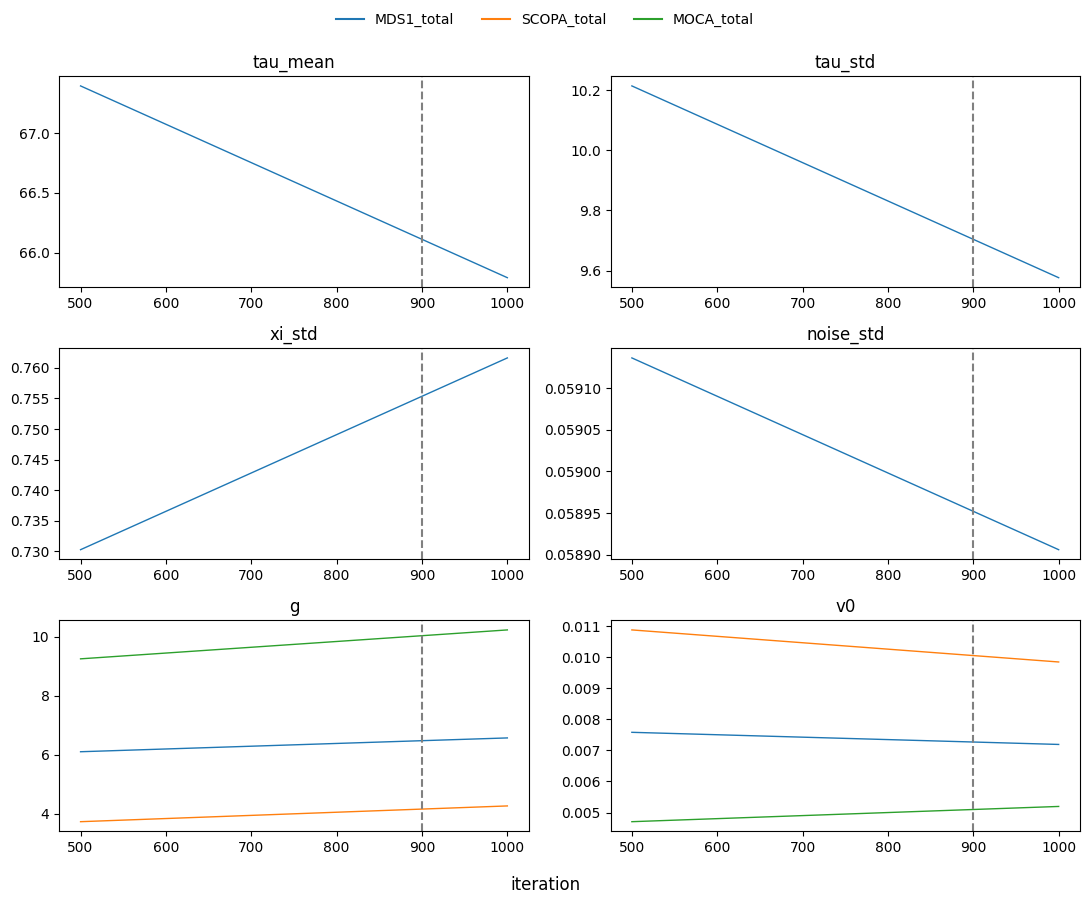

In [8]:
# Your own fit wrote one CSV per parameter into _outputs/parameter_convergence/.
plot_convergence("_outputs/parameter_convergence")
plt.show()

### Question

Take a look at the convergence plots above before answering.

In [9]:
tp.runquestion(3)

Do you think it has converged? If not, what would you try at first?
  [0] The model has converged
  [1] Revisit the data and verify monotonicity/normalization
  [2] Try a different model (e.g. linear)
  [3] Add more iterations


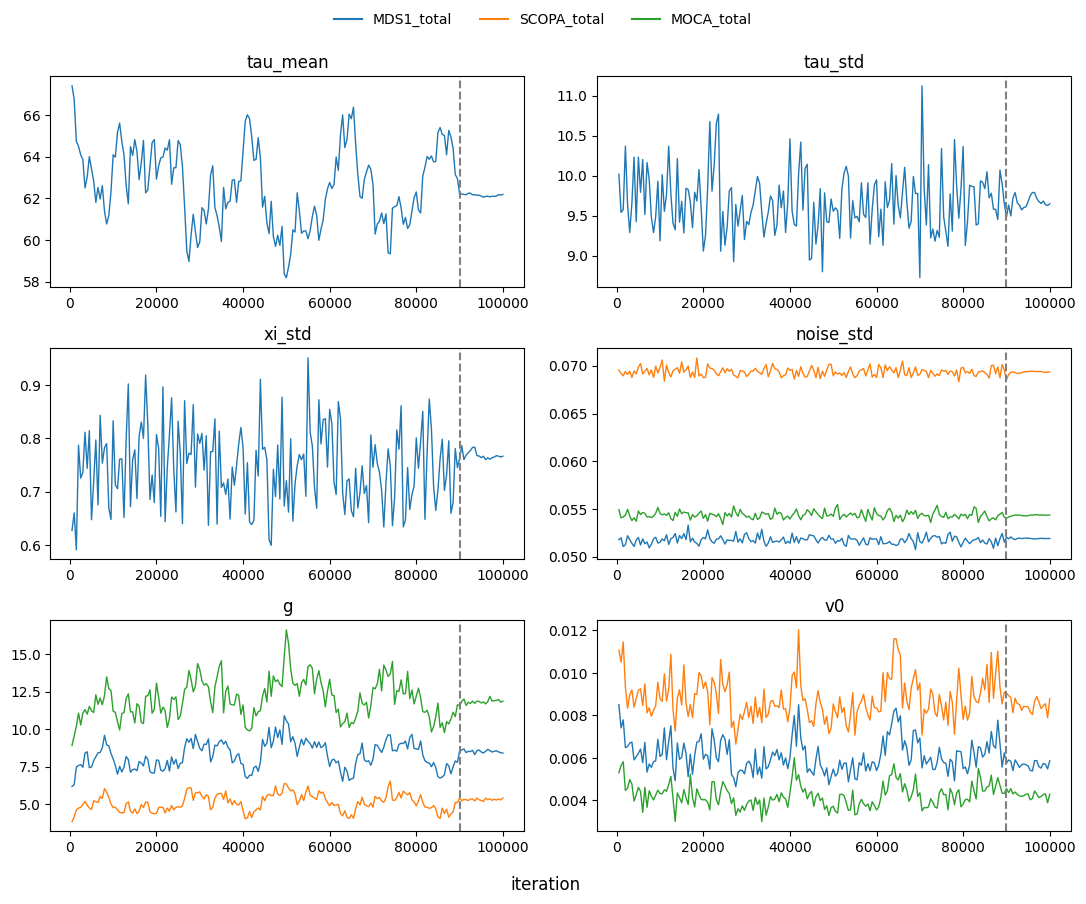

In [10]:
# The canonical 100 000-iteration run shipped with the tutorial
RUN = ROOT / "content" / "reference_run"

plot_convergence(RUN / "parameter_convergence")
plt.show()

**Note:** as shown above, 1000 iterations are not enough for the model to fully converge, so the parameters you just fitted are not the ones you would report in a real analysis.

Rather than draw conclusions from an under-converged fit, we ship the **converged** model: the result of that same 100 000-iteration run, saved to a JSON file. Loading it is instant, so from here on we can look at trustworthy parameters and trajectories without anyone waiting 11 minutes.

In [11]:
# Restoring a saved fit is a one-liner: same class, same API as the model you fitted above
model_100k = LogisticModel.load(str(RUN / "parkinson_fit_V21.json"))

print(type(model_100k).__name__, model_100k.features, f"source_dimension={model_100k.source_dimension}")
# on a loaded model these two are plain dicts, so they are read with [] not a dot
print(f"trained for {model_100k.training_info['n_iter']} iterations "
      f"on {model_100k.dataset_info['n_subjects']} subjects")

LogisticModel ['MDS1_total', 'SCOPA_total', 'MOCA_total'] source_dimension=2


AttributeError: 'LogisticModel' object has no attribute 'training_info'

## Model summary

Now that we have a model with a satisfactory convergence, we can look at its fit output via the integrated `summary()` function. Everything from here on reports `model_100k`, the converged fit -- not the 1000-iteration one you trained above.

In [ ]:
model_100k.summary()

AttributeError: 'LogisticModel' object has no attribute 'summary'

We can show specific elements such as the metrics:

In [ ]:
summary = model_100k.summary()
print(f"BIC: {float(summary.bic)}")
print(f"AIC: {float(summary.aic)}")

AttributeError: 'LogisticModel' object has no attribute 'summary'

Or a specific set of parameters

In [ ]:
model_100k.summary().parameters['Individual Parameters']

{'tau_mean': tensor([66.0522]),
 'tau_std': tensor([9.7451]),
 'xi_std': tensor([0.7576])}

## Plotting

We can plot the population trajectories of the converged model with leaspy's internal plotting tool.

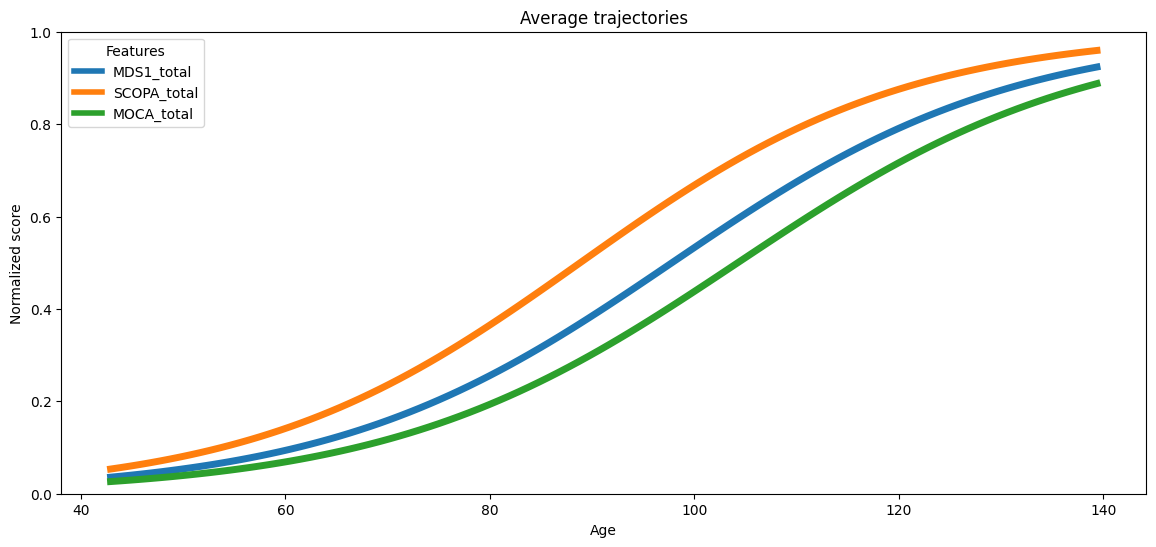

In [12]:
ax = Plotting(model_100k).average_trajectory(
    alpha=1, figsize=(14, 6), n_std_left=2, n_std_right=8
)
plt.show()

In [13]:
tp.show_asset("sigmoid_interactive.html")

/Users/maylis.tran/miniforge3/envs/leaspy_v2/lib/python3.11/site-packages/IPython/core/display.py:475: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## Model Comparison

One deliberate exception to what we just said: the exercises below go back to `model_2_sources`, the 1000-iteration fit.

BIC and AIC are only comparable between models trained the same way. Every model you are about to fit runs for 1000 iterations, so ranking them against `model_2_sources` compares the thing we are varying -- the number of sources, then the noise model. Slipping the converged `model_100k` into that ranking would mostly measure how long it trained, and it would win for the wrong reason.

In [14]:
tp.runquestion(5)

Both models give a negative BIC. Which one fits better?
  [0] The one with the BIC closest to zero
  [1] The one with the lowest (most negative) BIC
  [2] You cannot compare, BIC is only valid when positive


### Task 1: Vary the number of sources

Can you load and fit a logistic model with one source and compare it with the previous model?

model_1_source = ...

In [15]:
# If you need help, run this cell to get the code
# Click `Show Solution` to see the answer
tp.solution(1)

# A logistic model with a single source, fitted like the 2-source one
model_1_source = LogisticModel(name="logistic", source_dimension=1)

model_1_source.fit(
    df_train, "mcmc_saem",
    seed=SEED, n_iter=1000, progress_bar=True,
    save_periodicity=500,
    overwrite_logs_folder=True,
)

/Users/maylis.tran/Documents/These/dev/leaspy/src/leaspy/algo/settings.py:322: UserWarning: The parameters ['save_periodicity', 'overwrite_logs_folder'] were not present by default and are likely to be unsupported.
  warnings.warn(
/Users/maylis.tran/Documents/These/dev/leaspy/src/leaspy/algo/settings.py:69: UserWarning: Outputs will be saved in '_outputs' relative to the current working directory
  self._create_root_folder(settings)
/Users/maylis.tran/Documents/These/dev/leaspy/src/leaspy/algo/settings.py:150: UserWarning: Overwriting '/Users/maylis.tran/Documents/These/dev/leaspy_tutorial/notebooks/_outputs' folder...
  warnings.warn(f"Overwriting '{path}' folder...")
/Users/maylis.tran/miniforge3/envs/leaspy_v2/lib/python3.11/site-packages/torch/__init__.py:1236: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/work/pytorch/pytorch/

 ==> Setting seed to 0
|##################################################|   1000/1000 iterations

Fit with `AlgorithmName.FIT_MCMC_SAEM` took: 6s


In [16]:
# Now compare the two models with their BIC / AIC
tp.solution(2)

# Compare the two models: the lower the BIC / AIC, the better the fit
summary_2_sources = model_2_sources.summary()
summary_1_source = model_1_source.summary()

print("2 sources")
print(f"BIC: {float(summary_2_sources.bic)}")
print(f"AIC: {float(summary_2_sources.aic)}")
print("1 source")
print(f"BIC: {float(summary_1_source.bic)}")
print(f"AIC: {float(summary_1_source.aic)}")

AttributeError: 'LogisticModel' object has no attribute 'summary'

### Task 2: Vary the noise model

The default choice is to fit a `gaussian-diagonal` noise, which means that we fit a noise with a separate standard deviation per score


In [17]:
model_2_sources.observation_model_names

['gaussian-scalar']

Another option is to fit a `gaussian-scalar` noise, which means fitting one global standard deviation for the noise shared between all the scores.

We just have to add the argument `obs_models='gaussian-scalar'` when we load our model.

In [ ]:
tp.runquestion(6)

On 3 scores, switching from `gaussian-diagonal` to `gaussian-scalar` changes the number of model parameters by:
  [0] -2
  [1] 0
  [2] +1


In [ ]:
# Fit a 1-source model with a scalar noise
tp.solution(3)

# Same 1-source model, but with a single noise std shared by all the scores
model_scalar_1_source = LogisticModel(
    name="logistic", source_dimension=1, obs_models="gaussian-scalar"
)

model_scalar_1_source.fit(
    df_train, "mcmc_saem",
    seed=SEED, n_iter=1000, progress_bar=True,
    save_periodicity=500,
    overwrite_logs_folder=True,
)

 ==> Setting seed to 0
|#-------------------------------------------------|   20/1000 iterations

/Users/maylis.tran/Documents/These/dev/leaspy/src/leaspy/algo/settings.py:322: UserWarning: The parameters ['save_periodicity', 'overwrite_logs_folder'] were not present by default and are likely to be unsupported.
  warnings.warn(
/Users/maylis.tran/Documents/These/dev/leaspy/src/leaspy/algo/settings.py:69: UserWarning: Outputs will be saved in '_outputs' relative to the current working directory
  self._create_root_folder(settings)
/Users/maylis.tran/Documents/These/dev/leaspy/src/leaspy/algo/settings.py:150: UserWarning: Overwriting '/Users/maylis.tran/Documents/These/dev/leaspy_tutorial/notebooks/_outputs' folder...
  warnings.warn(f"Overwriting '{path}' folder...")


|##################################################|   1000/1000 iterations

Fit with `AlgorithmName.FIT_MCMC_SAEM` took: 5s


Let's fit also a model with 2 sources and a scalar noise and compare the four models all together.

In [ ]:
# Fit a 2-source model with a scalar noise
tp.solution(4)

# And the 2-source model with a scalar noise
model_scalar_2_sources = LogisticModel(
    name="logistic", source_dimension=2, obs_models="gaussian-scalar"
)

model_scalar_2_sources.fit(
    df_train, "mcmc_saem",
    seed=SEED, n_iter=1000, progress_bar=True,
    save_periodicity=500,
    overwrite_logs_folder=True,
)

 ==> Setting seed to 0
|#-------------------------------------------------|   20/1000 iterations

/Users/maylis.tran/Documents/These/dev/leaspy/src/leaspy/algo/settings.py:322: UserWarning: The parameters ['save_periodicity', 'overwrite_logs_folder'] were not present by default and are likely to be unsupported.
  warnings.warn(
/Users/maylis.tran/Documents/These/dev/leaspy/src/leaspy/algo/settings.py:69: UserWarning: Outputs will be saved in '_outputs' relative to the current working directory
  self._create_root_folder(settings)
/Users/maylis.tran/Documents/These/dev/leaspy/src/leaspy/algo/settings.py:150: UserWarning: Overwriting '/Users/maylis.tran/Documents/These/dev/leaspy_tutorial/notebooks/_outputs' folder...
  warnings.warn(f"Overwriting '{path}' folder...")


|##################################################|   1000/1000 iterations

Fit with `AlgorithmName.FIT_MCMC_SAEM` took: 7s


In [ ]:
# Compare the four models with their BIC / AIC
tp.solution(5)

# Compare the four models: the lower the BIC / AIC, the better the fit
models = {
    "Diagonal noise, 2 sources": model_2_sources,
    "Diagonal noise, 1 source": model_1_source,
    "Scalar noise, 2 sources": model_scalar_2_sources,
    "Scalar noise, 1 source": model_scalar_1_source,
}

for label, model in models.items():
    summary = model.summary()
    print(label)
    print(f"BIC: {float(summary.bic)}")
    print(f"AIC: {float(summary.aic)}")

AttributeError: 'LogisticModel' object has no attribute 'summary'

# Personalization and prediction

## Personalize on the train set

Fitting the model gives us **population-level** parameters — the average trajectory. But each patient deviates from this average: some start progressing earlier or later, some progress faster or slower. The `personalize` function estimates the **individual parameters** for each subject, conditional on the population parameters estimated during fit — namely, the time-shift $\tau_i$, the log-acceleration $\xi_i$, and the sources $s_i$, which together fully characterize a subject's individual trajectory.

From now on, we use the model fitted with 100 000 iterations (rather than the 1000-iteration model used earlier for the comparisons), since we now care about the quality of individual trajectories rather than just running fast comparisons.

Here we use `scipy_minimize`, a deterministic optimization method. Bayesian alternatives based on MCMC sampling are also available.

In [18]:
ip_train = model_100k.personalize(data_train, "scipy_minimize", seed=SEED, progress_bar=True)

 ==> Setting seed to 0
|--------------------------------------------------|   0/160 subjects

/Users/maylis.tran/Documents/These/dev/leaspy/src/leaspy/algo/personalize/scipy_minimize.py:632: UserWarning: In `scipy_minimize` you requested `use_jacobian=True` but it is not implemented in your model logistic. Falling back to `use_jacobian=False`...
  warnings.warn(


|#####################################################|   159/160 subjects

Personalize with `AlgorithmName.PERSONALIZE_SCIPY_MINIMIZE` took: 21s


This gives us, for each subject, their individual parameters. For instance, for patient `GS-001`:

In [19]:
print(ip_train["GS-001"])

{'sources': [-1.4973082542419434, 0.8063068985939026], 'tau': [68.5823745727539], 'xi': [1.4486241340637207]}


In the model summary of model_100k, we have seen that `tau_mean = 62.19` (the population's average disease onset age). Here, patient `GS-001` has `tau = 68.58` and a **log-acceleration factor** `xi = 1.45`.

In [20]:
tp.runquestion(7)

GS-001 has tau = 68.58, while tau_mean = 62.19 for the population. What does this imply?
  [0] GS-001 starts deteriorating earlier than average
  [1] GS-001 starts deteriorating later than average
  [2] GS-001 progresses faster than average
  [3] GS-001 progresses slower than average


In [21]:
tp.runquestion(8)

GS-001 has xi = 1.45 > 0. What does this imply?
  [0] GS-001 starts deteriorating earlier than average
  [1] GS-001 starts deteriorating later than average
  [2] GS-001 progresses faster than average
  [3] GS-001 progresses slower than average


We can verify this visually by plotting GS-001's individual trajectory alongside the population average.

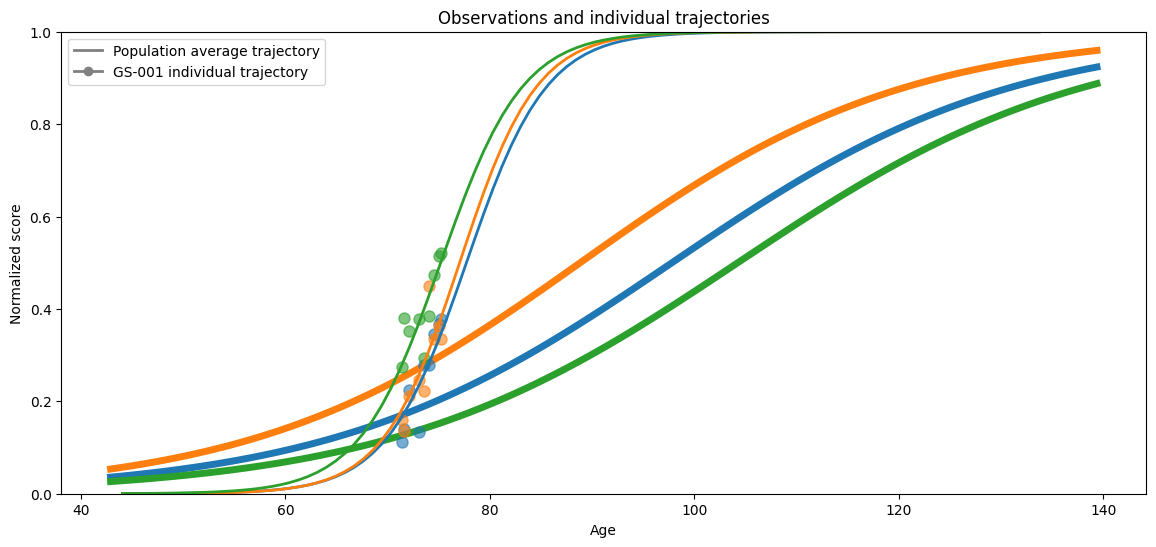

In [22]:
fig, ax = plt.subplots(figsize=(14, 6))
ax = Plotting(model_100k).average_trajectory(alpha=1, n_std_left=2, n_std_right=8, ax=ax)
ax = Plotting(model_100k).patient_trajectories(
    data_train, ip_train,
    patients_idx=["GS-001"],
    alpha=1, linestyle="-", linewidth=2, markersize=8, obs_alpha=0.6,
    figsize=(13, 5), factor_past=7, factor_future=15, ax=ax
)
ax.plot([], [], color="gray", linewidth=2, label="Population average trajectory")
ax.plot([], [], color="gray", linewidth=2, linestyle="-", marker="o", label="GS-001 individual trajectory")
ax.legend()
plt.show()

As expected, GS-001 indeed starts deteriorating later than the average patient, but progresses faster once the disease sets in.

### Reparametrized time

Each patient has their own pace: a personal onset age (`tau_i`) and a personal acceleretation factor (`xi_i`). **Reparametrized time** removes this individual variability, projecting every patient's trajectory onto the same underlying timeline.

Once reparametrized, patient trajectories should align closely with the population average trajectory. Let's check this by comparing the spaghetti plot in reparametrized time to the one in raw time (age) from earlier.

/var/folders/gt/1rv0s1150y728b0dy4n0dxf40000gq/T/ipykernel_8225/3753510165.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


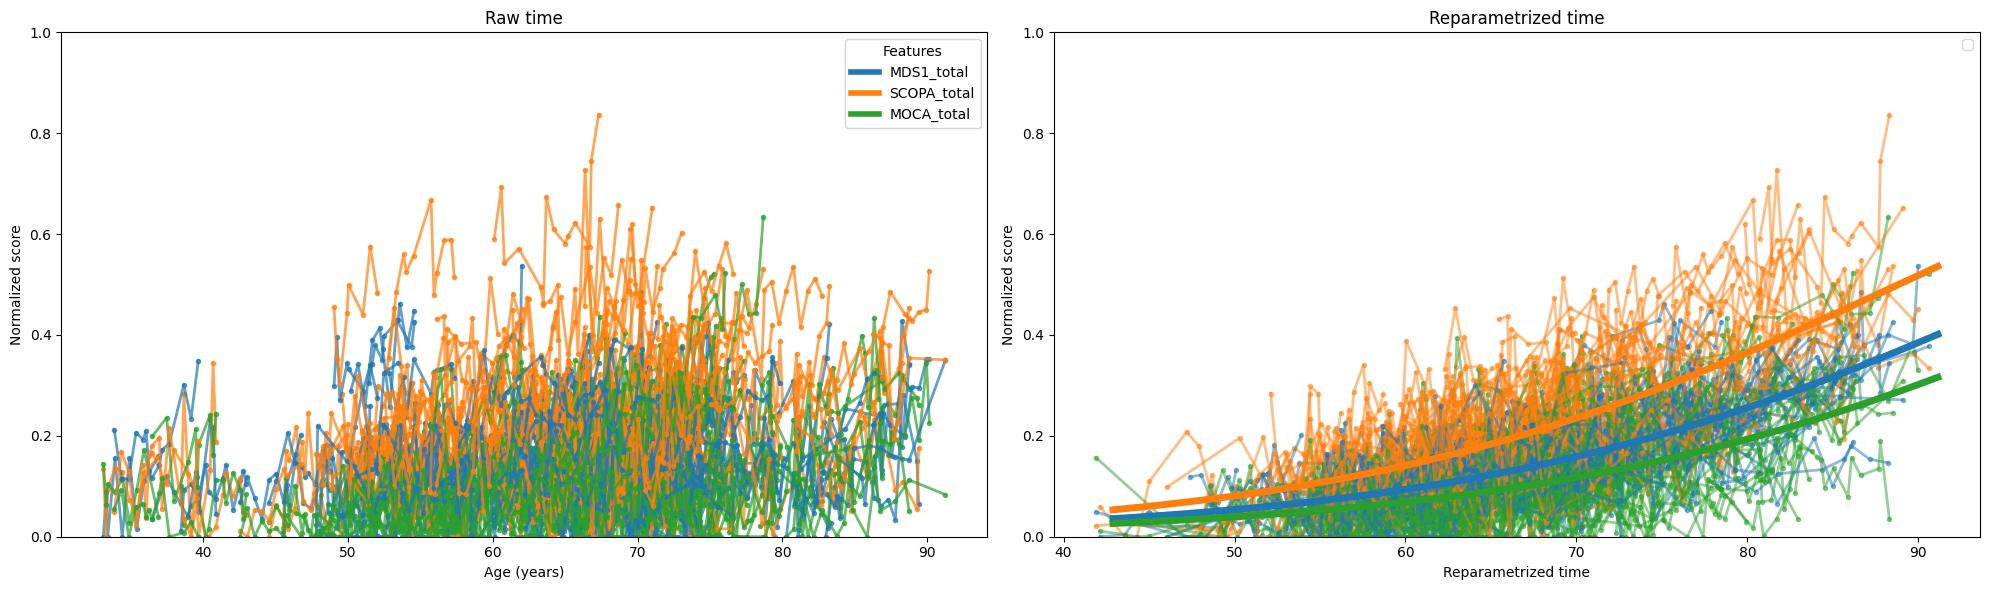

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Raw time
ax = axes[0]
ax = Plotting(model_100k).patient_observations(
    data_train, alpha=0.7, ax=ax
)
ax.set_xlabel("Age (years)")
ax.set_ylabel("Normalized score")
ax.set_title("Raw time")

# Reparametrized time
ax = axes[1]
ax = Plotting(model_100k).patient_observations_reparametrized(
    data_train, ip_train, alpha=0.5, linestyle="-", ax=ax
)
ax = Plotting(model_100k).average_trajectory(
    alpha=1, n_std_left=2, n_std_right=3, ax=ax
)
ax.set_xlabel("Reparametrized time")
ax.set_ylabel("Normalized score")
ax.set_title("Reparametrized time")
ax.legend()

plt.tight_layout()
plt.show()

The contrast is clear: in raw age, patient trajectories are spread out and hard to compare. In reparametrized time, they collapse around the population average trajectory.

## Predictions on the test set

Now that we understand how the `personalize` function access **individual parameters** for each subject, we can see how we can use these parameters to predict the progression of patients.

To do this, we use the test set, which contains patients not seen during model fitting. For each patient, we remove their last visit from the data used for personalization. Leaspy then estimates the patient's individual parameters using only their previous visits. These parameters are subsequently used to predict the feature values at the withheld final visit.

In [ ]:
tp.runquestion(8)

In [ ]:
# Load the data
df_test_partial = df_test.groupby("ID").apply(lambda x: x.iloc[:-1]).droplevel(0) # create the partial test set (without last visit)
data_test_partial = Data.from_dataframe(df_test_partial)

df_test_last = df_test.groupby("ID").tail(1) # create the test set with only the last visit (for evaluation metrics)

In [38]:
# Compute the individual parameters for the test set without last visit with the 100k-iteration model
tp.solution(6)

ip_test = model_100k.personalize(data_test_partial, "scipy_minimize", seed=SEED, progress_bar=True)

 ==> Setting seed to 0
|----------------------------------------|   0/40 subjects

/Users/maylis.tran/Documents/These/dev/leaspy/src/leaspy/algo/personalize/scipy_minimize.py:632: UserWarning: In `scipy_minimize` you requested `use_jacobian=True` but it is not implemented in your model logistic. Falling back to `use_jacobian=False`...
  warnings.warn(


|########################################|   40/40 subjects

Personalize with `AlgorithmName.PERSONALIZE_SCIPY_MINIMIZE` took: 5s


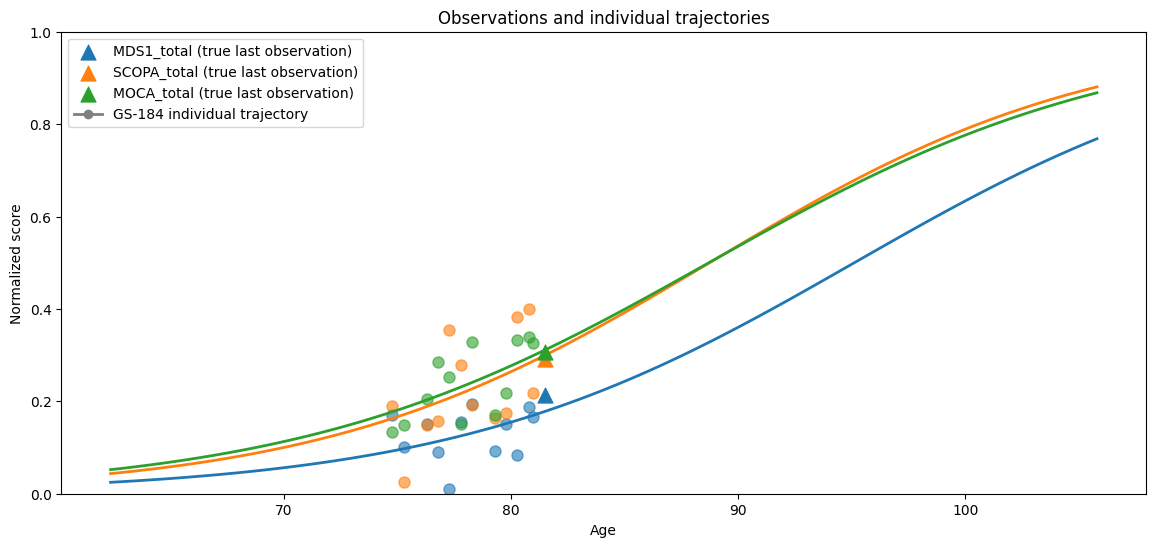

In [ ]:
# Plot individual trajectory for GS-184, with last observation marked
fig, ax = plt.subplots(figsize=(14, 6))
ax = Plotting(model_100k).patient_trajectories(
    data_test_partial, ip_test,
    patients_idx=["GS-184"],
    alpha=1, linestyle="-", linewidth=2, markersize=8, obs_alpha=0.6,
    figsize=(13, 5), factor_past=2, factor_future=4, ax=ax
)
for feature in ["MDS1_total", "SCOPA_total", "MOCA_total"]:
    ax.scatter(
        df_test_last.loc["GS-184"].index.get_level_values("TIME")[0],
        df_test_last.loc["GS-184"][feature].values[0],
        marker="^",  
        zorder=10,
        s = 120,
        linewidth=0.7,
        label=f"{feature} (true last observation)",
    )

ax.plot([], [], color="gray", linewidth=2, linestyle="-", marker="o", label="GS-184 individual trajectory")
ax.legend()
plt.show()

In the plot above, each feature trajectory is generated from the individual parameters `ip_test` estimated for patient GS-184. The triangle represents the true value at the final visit, which was intentionally removed before personalization.

Predicting this held-out value consists of evaluating the patient's estimated trajectory at the corresponding visit time $t$. This can be done using Leaspy's `estimate` function, which returns the predicted value of each feature along the trajectory.

In [ ]:
# Compute predictions at last visit time using estimate function
predicted_last = model_100k.estimate(df_test_last.index, ip_test)
for feature in FEATURES:
    mae = mean_absolute_error(df_test_last[feature], predicted_last[feature])
    r2  = r2_score(df_test_last[feature], predicted_last[feature])
    print(f"{feature}: MAE={mae:.3f}, R²={r2:.3f}")

MDS1_total: MAE=0.047, R²=0.761
SCOPA_total: MAE=0.060, R²=0.740
MOCA_total: MAE=0.047, R²=0.533


It is also possible to predict more than a single time point. Once the individual parameters have been estimated, the model can reconstruct the patient’s trajectory at any set of time points, including future visits.

In [36]:
# Compute predictions at other timepoints for GS-184
observations = df.loc["GS-184"]
print(f"Observed ages: {observations.index.values.round(1)}")

timepoints = np.linspace(81.5, 90, 10)
predicted = model_100k.estimate({"GS-184": timepoints}, ip_test)
print("reconstruction :", predicted)

Observed ages: [74.8 75.3 76.3 76.8 77.3 77.8 78.3 79.3 79.8 80.3 80.8 81.  81.5]
reconstruction : {'GS-184': array([[0.17809826, 0.29954684, 0.31105068],
       [0.19415969, 0.32328045, 0.3337863 ],
       [0.2112972 , 0.34796038, 0.35732186],
       [0.22951669, 0.37348476, 0.3815667 ],
       [0.24881141, 0.39973345, 0.406416  ],
       [0.26916155, 0.42657086, 0.43175387],
       [0.29053232, 0.45384777, 0.45745397],
       [0.31287375, 0.4814048 , 0.4833827 ],
       [0.336119  , 0.5090752 , 0.5094011 ],
       [0.36018598, 0.5366902 , 0.5353687 ]], dtype=float32)}
